PCA：协方差矩阵的特征值分解
数据形状: (150, 4)

协方差矩阵的形状: (4, 4)

特征值（方差）: [2.938 0.92  0.148 0.021]
特征向量（主成分方向）:
[[-0.521  0.377  0.72   0.261]
 [ 0.269  0.923 -0.244 -0.124]
 [-0.58   0.024 -0.142 -0.801]
 [-0.565  0.067 -0.634  0.524]]

每个主成分的解释方差比: [0.73  0.229 0.037 0.005]
前2个主成分累积解释: 0.958


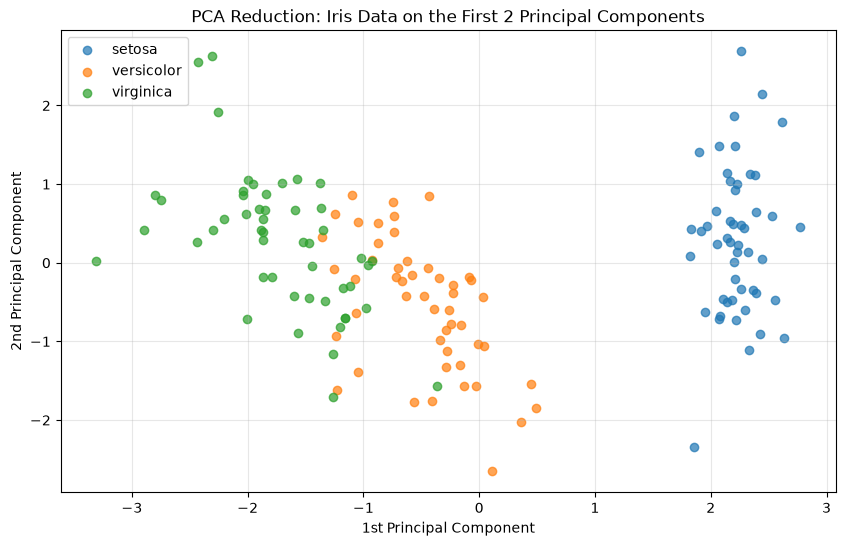

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# ---- 加载鸢尾花数据 ----
iris = load_iris()
X = iris.data
X_scaled = StandardScaler().fit_transform(X)

print("=" * 60)
print("PCA：协方差矩阵的特征值分解")
print("=" * 60)
print(f"数据形状: {X_scaled.shape}")

# ---- 计算协方差矩阵 ----
cov = np.cov(X_scaled.T)
print(f"\n协方差矩阵的形状: {cov.shape}")

# ---- 特征值分解 ----
eigenvalues, eigenvectors = np.linalg.eigh(cov)
# eigh 返回升序，我们反转
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print(f"\n特征值（方差）: {eigenvalues.round(3)}")
print(f"特征向量（主成分方向）:\n{eigenvectors.round(3)}")

# ---- 解释方差比 ----
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
print(f"\n每个主成分的解释方差比: {explained_variance_ratio.round(3)}")
print(f"前2个主成分累积解释: {explained_variance_ratio[:2].sum():.3f}")

# ---- 投影到前2个主成分 ----
X_pca = X_scaled @ eigenvectors[:, :2]

plt.figure(figsize=(10, 6))
for target in [0, 1, 2]:
    mask = iris.target == target
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=iris.target_names[target], alpha=0.7)
plt.xlabel('1st Principal Component')
plt.ylabel('2nd Principal Component')
# plt.title('PCA 降维：鸢尾花数据在前2个主成分上的投影')
plt.title('PCA Reduction: Iris Data on the First 2 Principal Components')
plt.legend()
plt.grid(alpha=0.3)
plt.show()